In [2]:
###################################################################

# Decay Functions for Euler, RK2, and ODEINT
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def decay_deriv(N,t):
    # The derivative in principle may depend on N and t -- in this
    # case, it only depends on N
    return -(1./tau) * N


def RK2_Solver(N0, tmin, tmax, nts, decay_deriv):
    N_array = np.zeros(nts)                                                     # array to hold number of nuclei
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    N_array[0] = N0                                                             # Initial number of nuclei
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        t  = t_array[it]                                                        
        N_h = N_array[it] + (dt/2 * decay_deriv(N_array[it], t))                # sub-step 1 for RK2
        N_array[it+1] = N_array[it] + (dt * decay_deriv(N_h, t + dt/2))         # sub-step 2 for RK2
    return t_array, N_array

def Euler_solver(N_initial, tmin, tmax, nts, deriv):
    N = np.zeros(nts+1)
    t = np.linspace(tmin, tmax, nts+1)
    
    # Note: a way of defining dt that is less error-prone
    dt = t[1] - t[0]
    N[0] = N_initial
    for it in range(0,nts):
        N[it+1] = N[it] + dt * deriv(N[it], t[it])
    return t, N

def diffeq_solver_from_scipy(N0, tmin, tmax, nts, decay_deriv):
    t = np.linspace(tmin, tmax, nts, endpoint=False)  
    N = odeint(decay_deriv, N0, t)
    return t, N



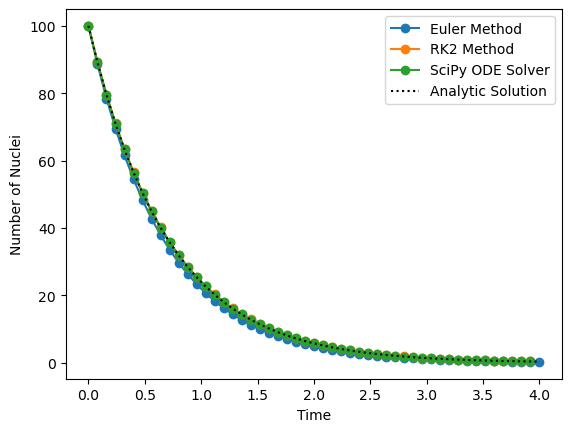

In [3]:
# parameters
tau = 0.7       # mean lifetime
N0 = 100.0      # initial number of nuclei
tmin = 0.0      # initial time
tmax = 4.0      # final time
nts = 50

# part b)
t_euler, N_euler = Euler_solver(N0, tmin, tmax, nts, decay_deriv)
t_rk2, N_rk2 = RK2_Solver(N0, tmin, tmax, nts, decay_deriv)
t_scipy, N_scipy = diffeq_solver_from_scipy(N0, tmin, tmax, nts, decay_deriv)
plt.plot(t_euler, N_euler, 'o-', label="Euler Method")
plt.plot(t_rk2, N_rk2, 'o-', label="RK2 Method")
plt.plot(t_scipy, N_scipy, 'o-', label="SciPy ODE Solver")
plt.plot(t_euler, N0*np.exp(-t_euler/tau), 'k:', label="Analytic Solution")       #t_euler = t_rk2 = t_scipy but its easier to separate them since the functions return t and N
plt.xlabel('Time')
plt.ylabel('Number of Nuclei')
plt.legend()
plt.show()

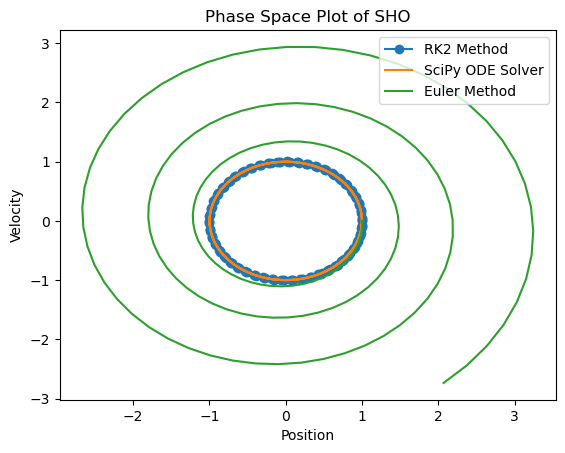

In [4]:
# Same thing except SHO instead of decay
# SHO Derivative

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def SHO_deriv(x_array, t):
    x, v = x_array
    dxdt = v
    dvdt = -k/m * x
    return [dxdt, dvdt]

# SHO functions
def SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                                                     # array to hold position
    v_array = np.zeros(nts)                                                     # array to hold velocity
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    x_array[0] = x0                                                             # Initial position
    v_array[0] = v0                                                             # Initial velocity
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        t  = t_array[it]                                                        
        x_h = x_array[it] + (dt/2 * SHO_deriv([x_array[it], v_array[it]], t)[0])                # sub-step 1 for RK2
        v_h = v_array[it] + (dt/2 * SHO_deriv([x_array[it], v_array[it]], t)[1])                # sub-step 1 for RK2
        x_array[it+1] = x_array[it] + (dt * SHO_deriv([x_h, v_h], t + dt/2)[0])         # sub-step 2 for RK2
        v_array[it+1] = v_array[it] + (dt * SHO_deriv([x_h, v_h], t + dt/2)[1])         # sub-step 2 for RK2
    return t_array, x_array, v_array

def SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv):
    t = np.linspace(tmin, tmax, nts, endpoint=False)  
    x_v_array = odeint(SHO_deriv, [x0, v0], t)
    x_array = x_v_array[:, 0]
    v_array = x_v_array[:, 1]
    return t, x_array, v_array

def SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv):
    x_array = np.zeros(nts)                           
    v_array = np.zeros(nts)                           
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)
    dt = t_array[1] - t_array[0]                        
    x_array[0] = x0                                     
    v_array[0] = v0                                     
    
    for it in range(0, nts-1):
        x_array[it+1] = x_array[it] + dt * SHO_deriv([x_array[it], v_array[it]], t_array[it])[0]
        v_array[it+1] = v_array[it] + dt * SHO_deriv([x_array[it], v_array[it]], t_array[it])[1]
    
    return t_array, x_array, v_array

# parameters for SHO
m = 1.0
k = 1.0
x0 = 1.0
v0 = 0.0
tmin = 0.0
tmax = 20.0
nts = 160
t_rk2, x_rk2, v_rk2 = SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv)
t_odeint, x_odeint, v_odeint = SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv)
t_euler, x_euler, v_euler = SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv)
plt.plot(x_rk2, v_rk2, '-o', label="RK2 Method")
plt.plot(x_odeint, v_odeint, label="SciPy ODE Solver")
plt.plot(x_euler, v_euler, label="Euler Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()


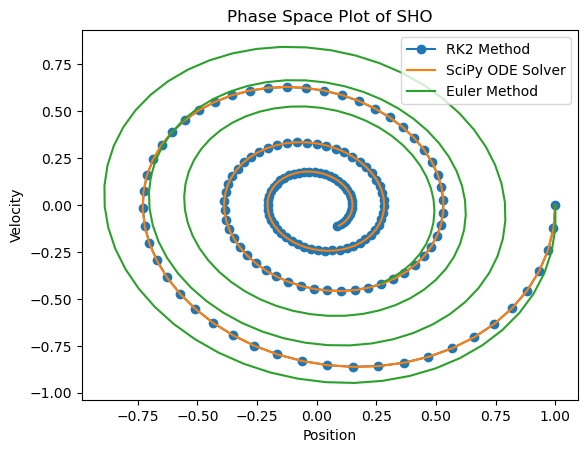

In [5]:
# now with linear damping term
def SHO_deriv_damped(x_array, t):
    x, v = x_array
    dxdt = v
    dvdt = -k/m * x - b/m * v
    return [dxdt, dvdt]

b=0.2

t_rk2, x_rk2, v_rk2 = SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
t_odeint, x_odeint, v_odeint = SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
t_euler, x_euler, v_euler = SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
plt.plot(x_rk2, v_rk2, '-o', label="RK2 Method")
plt.plot(x_odeint, v_odeint, label="SciPy ODE Solver")
plt.plot(x_euler, v_euler, label="Euler Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()

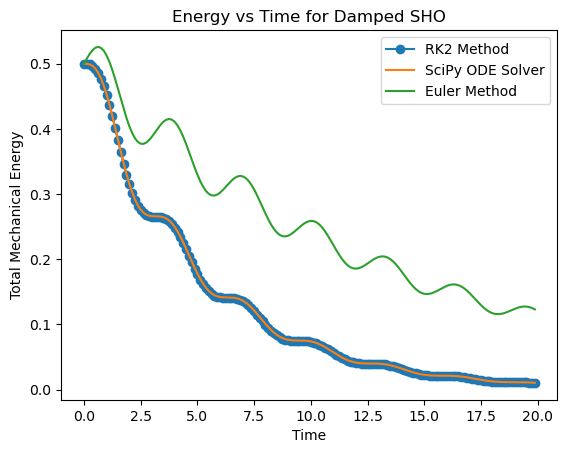

In [6]:
# How does the total mechanical energy (T+V) change over time with different solvers?

def H(x, v):
    T = 0.5 * m * v**2
    V = 0.5 * k * x**2
    return T + V

nts = 40

H_rk2 = H(x_rk2, v_rk2)
H_odeint = H(x_odeint, v_odeint)
H_euler = H(x_euler, v_euler)
plt.plot(t_rk2, H_rk2, '-o', label="RK2 Method")
plt.plot(t_odeint, H_odeint, label="SciPy ODE Solver")
plt.plot(t_euler, H_euler, label="Euler Method")
plt.xlabel('Time')
plt.ylabel('Total Mechanical Energy')
plt.title('Energy vs Time for Damped SHO')
plt.legend()
plt.show()

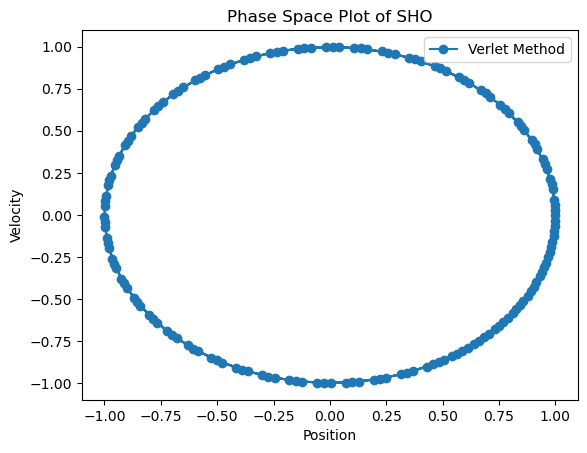

In [7]:
# Verlet and RK4 methods

import numpy as np
import matplotlib.pyplot as plt
# import rk4 and verlet from scipy
from scipy.integrate import solve_ivp
from scipy.integrate import RK45


def A_verlet_SHO(x_array, v_array):
        return -k/m * x_array                       # acceleration (x'') for SHO

def A_verlet_damped(x_array, v_array):
        return -k/m * x_array - b/m * v_array       # acceleration (x'') for damped SHO

def verlet_solver(x0, v0, tmin, tmax, nts, deriv):
    x_array = np.zeros(nts)                                                     # array to hold position
    v_array = np.zeros(nts)                                                     # array to hold velocity                                               
    t_array = np.linspace(tmin, tmax, nts, endpoint=False)                      # array holds the time points 
    dt = t_array[1] - t_array[0]                                                # dt = time step length  
    x_array[0] = x0                                                             # Initial position
    v_array[0] = v0                                                             # Initial velocity
    for it in range(0, len(t_array)-1 ):                                        # loop over time steps
        # Algorithm for Verlet method 
        x1 = x_array[it] + v_array[it]*dt + 0.5 * deriv(x_array[it], v_array[it]) * dt**2
        v1 = v_array[it] + 0.5 * (deriv(x_array[it], v_array[it]) + deriv(x1, v_array[it])) * dt
        x_array[it+1] = x1
        v_array[it+1] = v1


    return t_array, x_array, v_array


# parameters for SHO
m = 1.0
k = 1.0
x0 = 1.0
v0 = 0.0
tmin = 0.0
tmax = 20.0
nts = 160

#t_rk4, x_rk4, v_rk4 = rk4_solver(x0, v0, tmin, tmax, nts, SHO_deriv)
t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, tmin, tmax, nts, A_verlet_SHO)
#plt.plot(x_rk4, v_rk4, '-o', label="RK4 Method")
plt.plot(x_verlet, v_verlet, '-o', label="Verlet Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of SHO')
plt.legend()
plt.show()



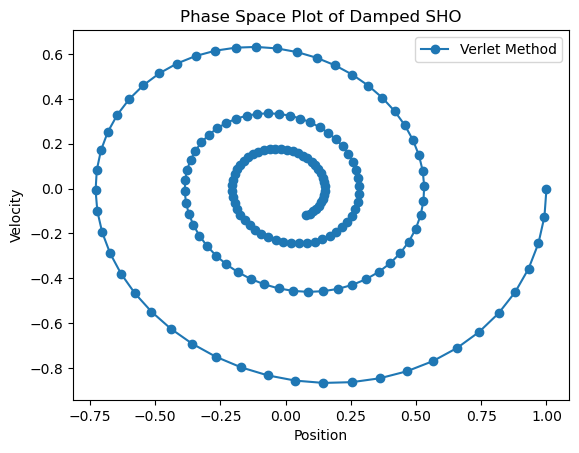

In [8]:
# using Verlet for damped SHO
b=0.2

t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, tmin, tmax, nts, A_verlet_damped)
plt.plot(x_verlet, v_verlet, '-o', label="Verlet Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space Plot of Damped SHO')
plt.legend()
plt.show()

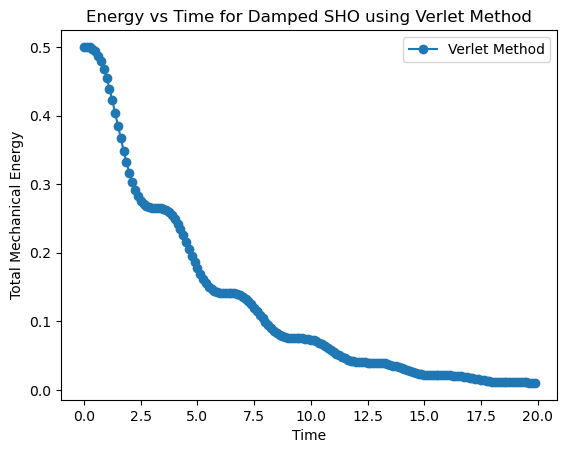

In [9]:
# energy vs time for Verlet method
H_verlet = H(x_verlet, v_verlet)
plt.plot(t_verlet, H_verlet, '-o', label="Verlet Method")
plt.xlabel('Time')
plt.ylabel('Total Mechanical Energy')
plt.title('Energy vs Time for Damped SHO using Verlet Method')
plt.legend()

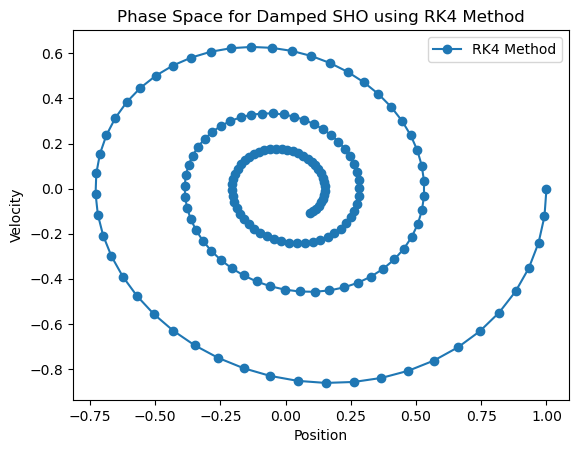

In [10]:
# using scipy for RK4
from scipy.integrate import RK45
# parameters that are required 
def fun(t, y):
    x, v = y
    dxdt = v
    dvdt = -k/m * x - b/m * v
    return [dxdt, dvdt]

t_eval = np.linspace(tmin, tmax, nts, endpoint=False)
sol = solve_ivp(fun, (tmin, tmax), [x0, v0], t_eval=t_eval, method='RK45')
t_rk4 = sol.t
x_rk4 = sol.y[0]
v_rk4 = sol.y[1]
plt.plot(x_rk4, v_rk4, '-o', label="RK4 Method")
plt.xlabel('Position')
plt.ylabel('Velocity')
plt.title('Phase Space for Damped SHO using RK4 Method')
plt.legend()
plt.show()

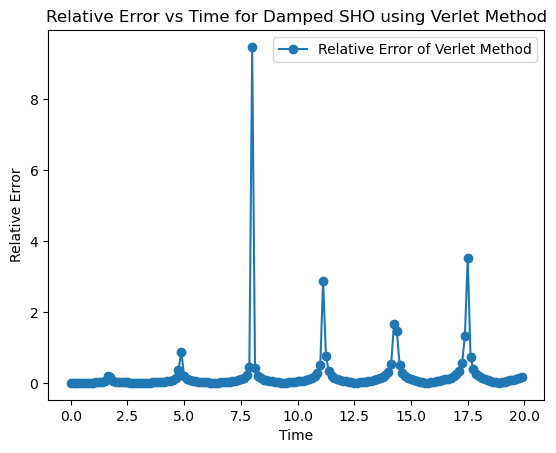

In [11]:
# NOw I want to be able to compute relative errors

def analytical_SHO(t):
    omega = np.sqrt(k/m)
    A = np.sqrt(x0**2 + (v0/omega)**2)
    phi = np.arctan(v0/(omega*x0))
    return A * np.cos(omega*t - phi)

def analytical_damped_SHO(t):
    omega0 = np.sqrt(k/m)
    gamma = b/(2*m)
    omega_d = np.sqrt(omega0**2 - gamma**2)
    A = np.sqrt(x0**2 + ((v0 + gamma*x0)/omega_d)**2)
    phi = np.arctan((v0 + gamma*x0)/(omega_d*x0))
    return A * np.exp(-gamma*t) * np.cos(omega_d*t - phi)

def relative_error(numerical, analytical):
    return np.abs(numerical - analytical) / np.abs(analytical)

relative_error_verlet = relative_error(x_verlet, analytical_damped_SHO(t_verlet))
plt.plot(t_verlet, relative_error_verlet, '-o', label="Relative Error of Verlet Method")
plt.xlabel('Time')
plt.ylabel('Relative Error')
plt.title('Relative Error vs Time for Damped SHO using Verlet Method')
plt.legend()

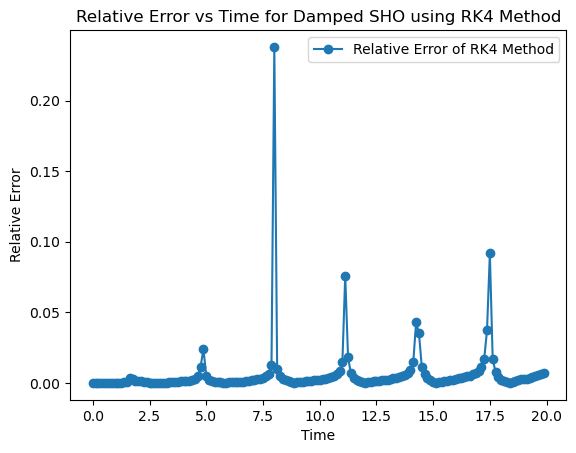

In [12]:
relative_error_rk4 = relative_error(x_rk4, analytical_damped_SHO(t_rk4))
plt.plot(t_rk4, relative_error_rk4, '-o', label="Relative Error of RK4 Method")
plt.xlabel('Time')
plt.ylabel('Relative Error')
plt.title('Relative Error vs Time for Damped SHO using RK4 Method')
plt.legend()

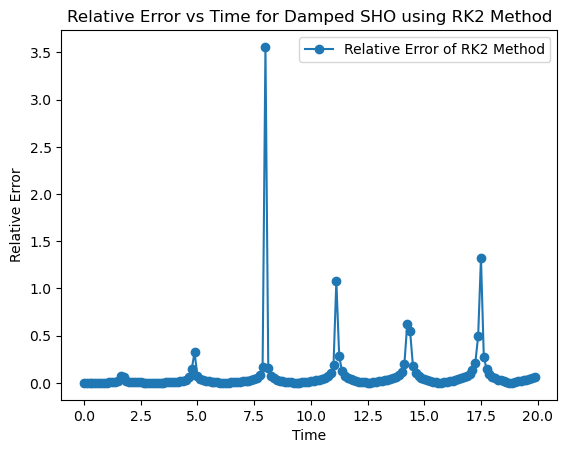

In [43]:
relative_error_rk2 = relative_error(x_rk2, analytical_damped_SHO(t_rk2))
plt.plot(t_rk2, relative_error_rk2, '-o', label="Relative Error of RK2 Method")
plt.xlabel('Time')
plt.ylabel('Relative Error')
plt.title('Relative Error vs Time for Damped SHO using RK2 Method')
plt.legend()

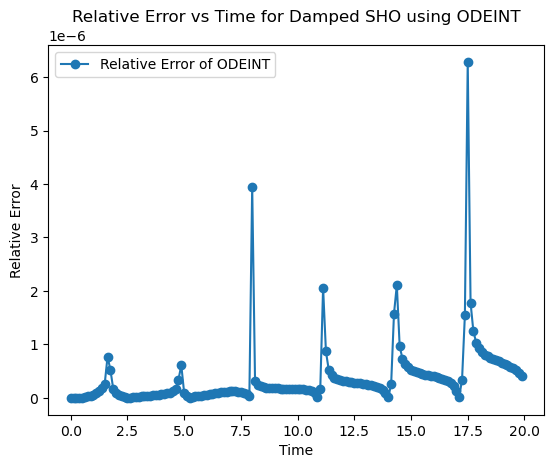

In [13]:
relative_error_odeint = relative_error(x_odeint, analytical_damped_SHO(t_odeint))
plt.plot(t_odeint, relative_error_odeint, '-o', label="Relative Error of ODEINT")
plt.xlabel('Time')
plt.ylabel('Relative Error')
plt.title('Relative Error vs Time for Damped SHO using ODEINT')
plt.legend()

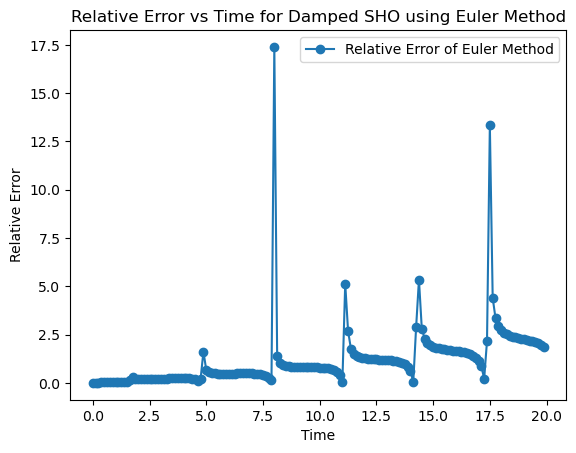

In [45]:
relative_error_euler = relative_error(x_euler, analytical_damped_SHO(t_euler))
plt.plot(t_euler, relative_error_euler, '-o', label="Relative Error of Euler Method")
plt.xlabel('Time')
plt.ylabel('Relative Error')
plt.title('Relative Error vs Time for Damped SHO using Euler Method')
plt.legend()

In [53]:
# relative error for each method at some constant tmax
tmax = 6.5
relative_error_verlet_at_tmax = relative_error(x_verlet[-1], analytical_damped_SHO(tmax))
relative_error_rk4_at_tmax = relative_error(x_rk4[-1], analytical_damped_SHO(tmax))
relative_error_rk2_at_tmax = relative_error(x_rk2[-1], analytical_damped_SHO(tmax))
relative_error_odeint_at_tmax = relative_error(x_odeint[-1], analytical_damped_SHO(tmax))
relative_error_euler_at_tmax = relative_error(x_euler[-1], analytical_damped_SHO(tmax))
print(f"Relative error at t={tmax} for Verlet method: {relative_error_verlet_at_tmax:.6e}")
print(f"Relative error at t={tmax} for RK4 method: {relative_error_rk4_at_tmax:.6e}")
print(f"Relative error at t={tmax} for RK2 method: {relative_error_rk2_at_tmax:.6e}")
print(f"Relative error at t={tmax} for ODEINT method: {relative_error_odeint_at_tmax:.6e}")
print(f"Relative error at t={tmax} for Euler method: {relative_error_euler_at_tmax:.6e}")

Relative error at t=6.5 for Verlet method: 8.493326e-01
Relative error at t=6.5 for RK4 method: 8.476930e-01
Relative error at t=6.5 for RK2 method: 8.475941e-01
Relative error at t=6.5 for ODEINT method: 8.475745e-01
Relative error at t=6.5 for Euler method: 8.470933e-01


In [51]:
# number of time steps needed to reach a targer error
target_error = 0.01
nts = [2**k for k in range(1, 15)]  # powers of 2
for nts in nts:
    t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, tmin, tmax, nts, A_verlet_damped)
    relative_error_verlet_at_tmax = relative_error(x_verlet[-1], analytical_damped_SHO(tmax))
    if relative_error_verlet_at_tmax < target_error:
        print(f"Verlet method achieves relative error < {target_error} at t={tmax} with nts={nts}")
        break

nts = [2**k for k in range(1, 15)]  # powers of 2
for nts in nts:
    t_rk4, x_rk4, v_rk4 = solve_ivp(fun, (tmin, tmax), [x0, v0], t_eval=np.linspace(tmin, tmax, nts, endpoint=False), method='RK45').t, solve_ivp(fun, (tmin, tmax), [x0, v0], t_eval=np.linspace(tmin, tmax, nts, endpoint=False), method='RK45').y[0], solve_ivp(fun, (tmin, tmax), [x0, v0], t_eval=np.linspace(tmin, tmax, nts, endpoint=False), method='RK45').y[1]
    relative_error_rk4_at_tmax = relative_error(x_rk4[-1], analytical_damped_SHO(tmax))
    if relative_error_rk4_at_tmax < target_error:
        print(f"RK4 method achieves relative error < {target_error} at t={tmax} with nts={nts}")
        break

nts = [2**k for k in range(1, 15)]  # powers of 2
for nts in nts:
    t_rk2, x_rk2, v_rk2 = SHO_solver_RK2(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
    relative_error_rk2_at_tmax = relative_error(x_rk2[-1], analytical_damped_SHO(tmax))
    if relative_error_rk2_at_tmax < target_error:
        print(f"RK2 method achieves relative error < {target_error} at t={tmax} with nts={nts}")
        break

nts = [2**k for k in range(1, 15)]  # powers of 2
for nts in nts:
    t_odeint, x_odeint, v_odeint = SHO_solver_ODEINT(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
    relative_error_odeint_at_tmax = relative_error(x_odeint[-1], analytical_damped_SHO(tmax))
    if relative_error_odeint_at_tmax < target_error:
        print(f"ODEINT method achieves relative error < {target_error} at t={tmax} with nts={nts}")
        break

nts = [2**k for k in range(1, 15)]  # powers of 2
for nts in nts:
    t_euler, x_euler, v_euler = SHO_solver_Euler(x0, v0, tmin, tmax, nts, SHO_deriv_damped)
    relative_error_euler_at_tmax = relative_error(x_euler[-1], analytical_damped_SHO(tmax))
    if relative_error_euler_at_tmax < target_error:
        print(f"Euler method achieves relative error < {target_error} at t={tmax} with nts={nts}")
        break


Verlet method achieves relative error < 0.01 at t=20.0 with nts=512
RK4 method achieves relative error < 0.01 at t=20.0 with nts=2048
RK2 method achieves relative error < 0.01 at t=20.0 with nts=4096
ODEINT method achieves relative error < 0.01 at t=20.0 with nts=4096


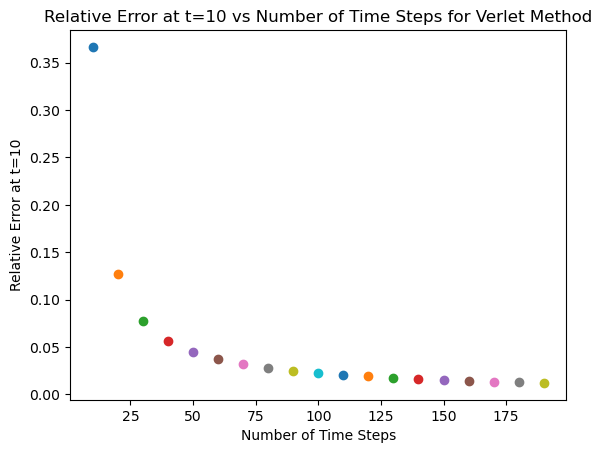

In [20]:
# plot error vs time steps at some tmax
tmax = 10.0
nts = [10*k for k in range(1, 20)]  # powers of 2
for nts in nts:
    t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, tmin, tmax, nts, A_verlet_damped)
    relative_error_verlet_at_tmax = relative_error(x_verlet[-1], analytical_damped_SHO(tmax))
    plt.plot(nts, relative_error_verlet_at_tmax, 'o-', label="Verlet Method")
    plt.xlabel('Number of Time Steps')
    plt.ylabel('Relative Error at t=10')
    plt.title('Relative Error at t=10 vs Number of Time Steps for Verlet Method')
plt.show()

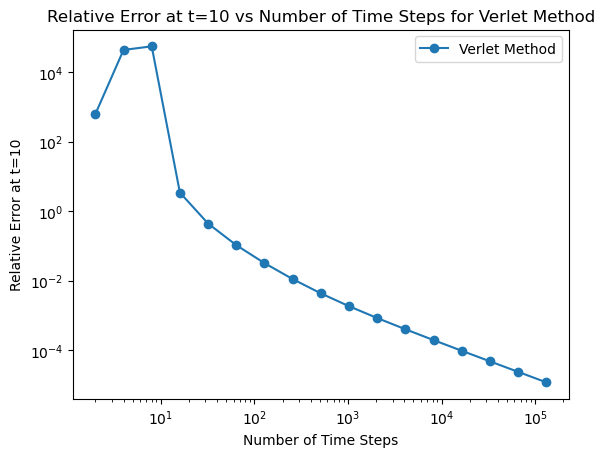

Slope of log-log plot: -1.60


In [50]:
# log plot error vs time steps at some tmax, and print the slope of the line
tmax = 20.0
nts_list = [2**k for k in range(1, 18)]  # powers of 2

#relative_errors = []
relative_errors = np.zeros(len(nts_list))

for nts in nts_list:
    t_verlet, x_verlet, v_verlet = verlet_solver(x0, v0, 0, tmax, nts, A_verlet_damped)
    err = relative_error(x_verlet[-1], analytical_damped_SHO(tmax))
    #relative_errors.append(err)
    relative_errors[nts_list.index(nts)] = err

plt.loglog(nts_list, relative_errors, 'o-', label="Verlet Method")
plt.xlabel('Number of Time Steps')
plt.ylabel('Relative Error at t=10')
plt.title('Relative Error at t=10 vs Number of Time Steps for Verlet Method')
plt.legend()
plt.show()

# print slope of line
log_nts = np.log(nts_list)
log_errors = np.log(relative_errors)
slope = (log_errors[-1] - log_errors[0]) / (log_nts[-1] - log_nts[0])
print(f"Slope of log-log plot: {slope:.2f}")

In [45]:
print(x0, v0)

1.0 0.0
